1) Detect cracks in metallic/ceramic surfaces using classical image techniques

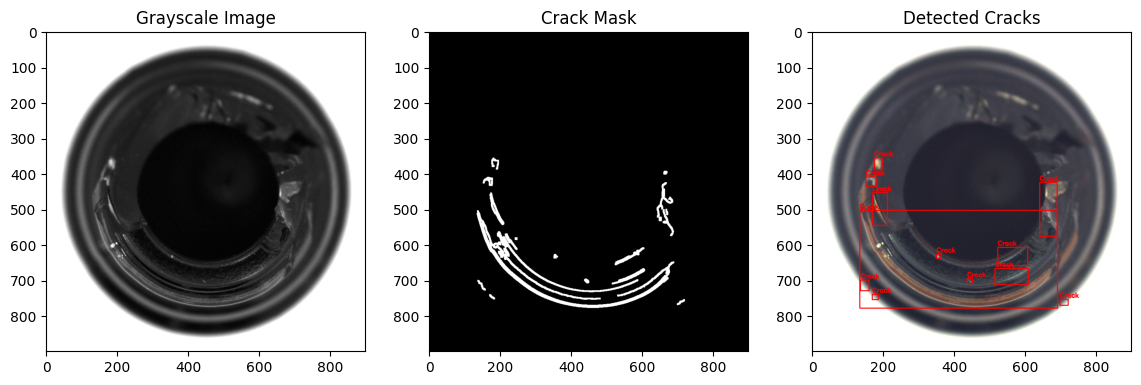

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("002.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

kernel = np.ones((3,3), np.uint8)

closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

dilated = cv2.dilate(closed, kernel, iterations=2)

contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()

for c in contours:
    area = cv2.contourArea(c)
    if area > 100:
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,0,255), 2)
        cv2.putText(output, "Crack", (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

plt.figure(figsize=(14,7))
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")

plt.subplot(1,3,2)
plt.imshow(dilated, cmap='gray')
plt.title("Crack Mask")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Cracks")
plt.show()


3. Classify a crack segmentation task into calibrated width measurements and severity
classes (narrow/medium/wide).

Avg Crack Width: 172.65px → WIDE


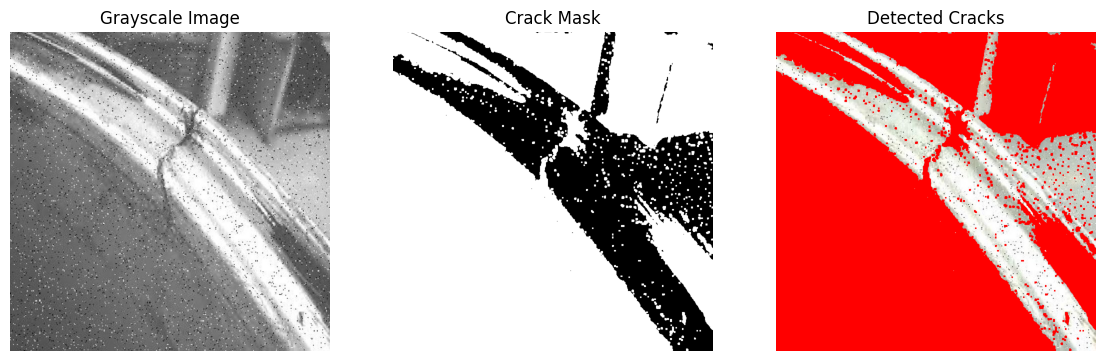

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def crack_width_and_severity(path):
    img = cv2.imread(path)
    if img is None:
        print("Image not found")
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    # Distance transform for width
    dist = cv2.distanceTransform(dilated, cv2.DIST_L2, 5)
    widths = dist[dilated == 255] * 2

    if len(widths) == 0:
        print("No crack found")
        return

    avg_width = np.mean(widths)

    if avg_width < 2:
        severity = "NARROW"
    elif avg_width < 5:
        severity = "MEDIUM"
    else:
        severity = "WIDE"

    print(f"Avg Crack Width: {avg_width:.2f}px → {severity}")

    # Overlay result
    output = img.copy()
    output[dilated == 255] = [0,0,255]

    # Fresh plotting
    plt.figure(figsize=(14,7))

    plt.subplot(1,3,1)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(dilated, cmap="gray")
    plt.title("Crack Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Detected Cracks")
    plt.axis("off")

    plt.show()

crack_width_and_severity("weld.jpg")



5. Implement PCB inspection via template matching

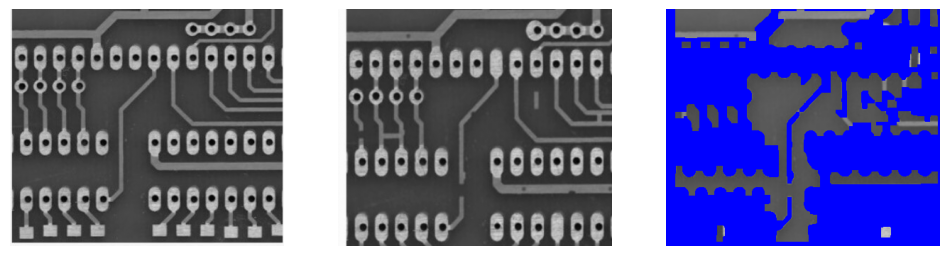

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref_path = "goodpcb.jpg"
test_path = "template.jpg"

ref = cv2.imread(ref_path, 0)
test = cv2.imread(test_path, 0)

fx = ref.shape[1] / test.shape[1]
fy = ref.shape[0] / test.shape[0]
test = cv2.resize(test, None, fx=fx, fy=fy)

diff = cv2.absdiff(ref, test)
blur = cv2.GaussianBlur(diff, (5,5), 0)
_, th = cv2.threshold(blur, 30, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

overlay = cv2.cvtColor(test, cv2.COLOR_GRAY2BGR)
overlay[clean>0] = (0,0,255)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(ref, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(test, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis('off')
plt.show()

6. Precisely localize PCB defects via golden template alignment + keypoints

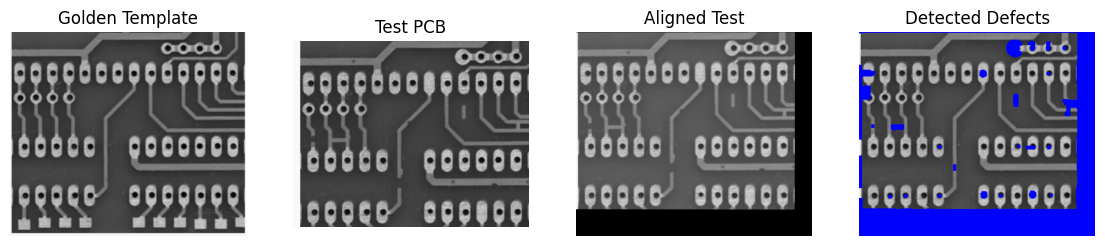

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref_path = "/content/goodpcb.jpg"
test_path = "/content/template.jpg"

ref = cv2.imread(ref_path, 0)
test = cv2.imread(test_path, 0)

orb = cv2.ORB_create(5000)
kp1, des1 = orb.detectAndCompute(ref, None)
kp2, des2 = orb.detectAndCompute(test, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

aligned = cv2.warpPerspective(test, H, (ref.shape[1], ref.shape[0]))

diff = cv2.absdiff(ref, aligned)
blur = cv2.GaussianBlur(diff, (7,7), 0)
_, th = cv2.threshold(blur, 25, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

overlay = cv2.cvtColor(ref, cv2.COLOR_GRAY2BGR)
overlay[clean>0] = (0,0,255)

plt.figure(figsize=(14,4))
plt.subplot(1,4,1); plt.imshow(ref, cmap='gray'); plt.title("Golden Template"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(test, cmap='gray'); plt.title("Test PCB"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(aligned, cmap='gray'); plt.title("Aligned Test"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(overlay); plt.title("Detected Defects"); plt.axis('off')
plt.show()


7. Segment and classify surface defects using rule-based pipelines

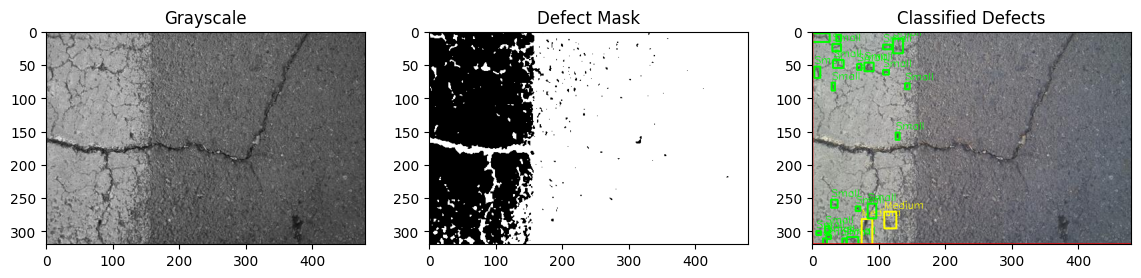

In [11]:
def surface_defect_classification(image_path):
    import cv2, numpy as np, matplotlib.pyplot as plt

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(blur, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = img.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue

        x,y,w,h = cv2.boundingRect(cnt)

        if area < 100:
            label,color = "Small",(0,255,0)
        elif area < 500:
            label,color = "Medium",(0,255,255)
        else:
            label,color = "Large",(0,0,255)

        cv2.rectangle(output,(x,y),(x+w,y+h),color,2)
        cv2.putText(output,label,(x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,color,1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    plt.imshow(gray,cmap="gray")
    plt.title("Grayscale")

    plt.subplot(1,3,2)
    plt.imshow(mask,cmap="gray")
    plt.title("Defect Mask")

    plt.subplot(1,3,3)
    plt.imshow(output[:,:,::-1])
    plt.title("Classified Defects")

    plt.show()
surface_defect_classification("/content/surface.jpg")


8. Analyze IR thermal maps to detect abnormal heating zones

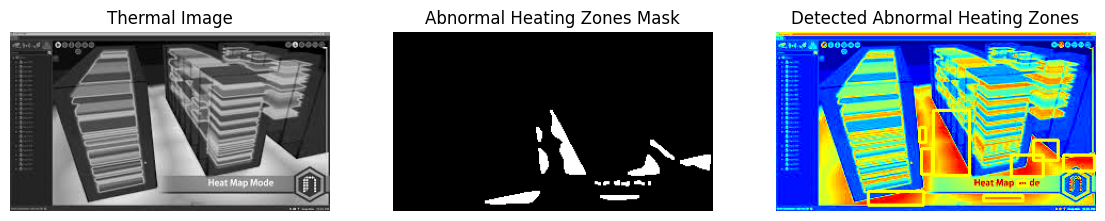

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_abnormal_heating(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Image not loaded")
        return

    # Blur to reduce noise
    blur = cv2.GaussianBlur(img, (5,5), 0)

    # Find hot areas (top 5% intensity)
    thresh_val = np.percentile(blur, 95)
    _, hot_mask = cv2.threshold(blur, int(thresh_val), 255, cv2.THRESH_BINARY)

    # Remove noise
    kernel = np.ones((3,3), np.uint8)
    hot_clean = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel, 1)

    # Convert to heat map for visualization
    heatmap = cv2.applyColorMap(img, cv2.COLORMAP_JET)

    # Draw bounding boxes around hot zones
    contours, _ = cv2.findContours(hot_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = heatmap.copy()

    for cnt in contours:
        if cv2.contourArea(cnt) < 20:
            continue
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,255), 2)

    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Thermal Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(hot_clean, cmap='gray')
    plt.title("Abnormal Heating Zones Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Detected Abnormal Heating Zones")
    plt.axis("off")

    plt.show()
detect_abnormal_heating("images.jpg")


9. Using visual analytics, detect thermal anomalies in images with annotated hot spots.

Detected Hotspots:
Hotspot 1: Area=122.00, Mean Intensity=194.91
Hotspot 2: Area=336.50, Mean Intensity=172.92
Hotspot 3: Area=21.00, Mean Intensity=200.84
Hotspot 4: Area=237.00, Mean Intensity=184.40
Hotspot 5: Area=263.50, Mean Intensity=161.79
Hotspot 6: Area=133.00, Mean Intensity=192.41
Hotspot 7: Area=98.00, Mean Intensity=144.86
Hotspot 8: Area=47.00, Mean Intensity=197.54
Hotspot 9: Area=631.50, Mean Intensity=142.73


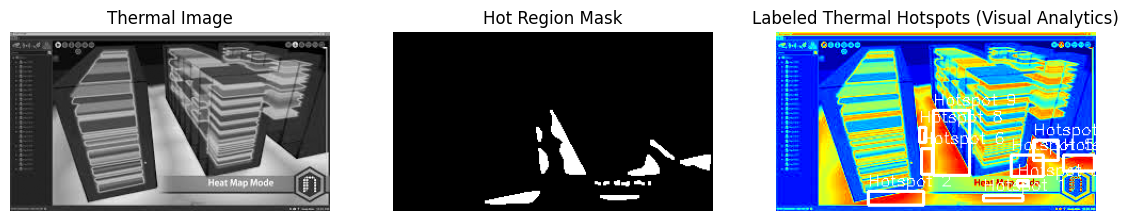

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def thermal_analytics(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Image not loaded")
        return

    blur = cv2.GaussianBlur(img, (5,5), 0)

    thresh_val = np.percentile(blur, 95)
    _, hot_mask = cv2.threshold(blur, int(thresh_val), 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3), np.uint8)
    hot_clean = cv2.morphologyEx(hot_mask, cv2.MORPH_OPEN, kernel, 1)

    heatmap = cv2.applyColorMap(img, cv2.COLORMAP_JET)

    contours, _ = cv2.findContours(hot_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = heatmap.copy()
    hotspot_id = 1

    print("Detected Hotspots:")
    for cnt in contours:
        if cv2.contourArea(cnt) < 20:
            continue

        x,y,w,h = cv2.boundingRect(cnt)
        roi = img[y:y+h, x:x+w]
        mean_temp = np.mean(roi)

        cv2.rectangle(output, (x,y), (x+w,y+h), (255,255,255), 2)
        cv2.putText(output, f"Hotspot {hotspot_id}",
                    (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255,255,255), 1)

        print(f"Hotspot {hotspot_id}: Area={cv2.contourArea(cnt):.2f}, Mean Intensity={mean_temp:.2f}")

        hotspot_id += 1

    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Thermal Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(hot_clean, cmap="gray")
    plt.title("Hot Region Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Labeled Thermal Hotspots (Visual Analytics)")
    plt.axis("off")

    plt.show()
thermal_analytics("images.jpg")

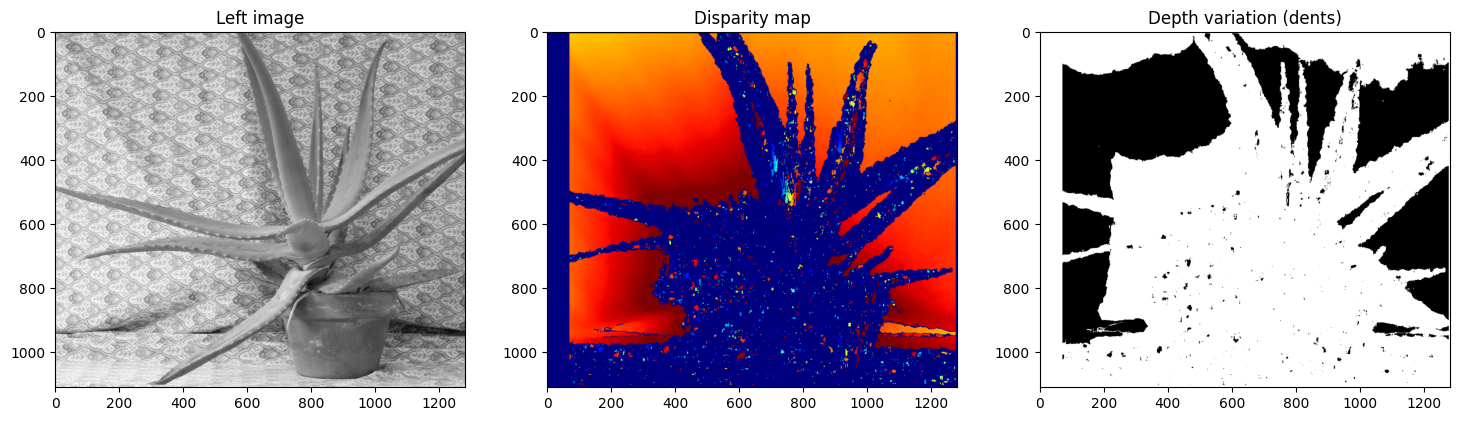

In [23]:
import cv2, numpy as np, matplotlib.pyplot as plt
import urllib.request

left_url  = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeL.jpg"
right_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeR.jpg"

urllib.request.urlretrieve(left_url, "left.jpg")
urllib.request.urlretrieve(right_url, "right.jpg")

imgL = cv2.imread("left.jpg", cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread("right.jpg", cv2.IMREAD_GRAYSCALE)

stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disparity = stereo.compute(imgL, imgR).astype(np.float32) / 16.0

disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

median_disp = np.median(disparity[np.where(disparity>0)])
depth_diff = np.abs(disparity - median_disp)
dents_mask = (depth_diff > 5).astype(np.uint8) * 255

plt.figure(figsize=(18,6))
plt.subplot(1,3,1); plt.title("Left image");    plt.imshow(imgL, cmap='gray')
plt.subplot(1,3,2); plt.title("Disparity map"); plt.imshow(disp_vis, cmap='jet')
plt.subplot(1,3,3); plt.title("Depth variation (dents)"); plt.imshow(dents_mask, cmap='gray')
plt.show()
